In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import os

In [5]:
os.chdir("/Users/kaiping/Desktop/olist_project/data") 
os.getcwd()

'/Users/kaiping/Desktop/olist_project/data'

In [6]:
df_translation = pd.read_csv("raw/product_category_name_translation.csv")
df_sellers     = pd.read_csv("raw/olist_sellers_dataset.csv")
df_products    = pd.read_csv("raw/olist_products_dataset.csv")
df_orders      = pd.read_csv("raw/olist_orders_dataset.csv")
df_order_reviews  = pd.read_csv("raw/olist_order_reviews_dataset.csv")
df_order_payments = pd.read_csv("raw/olist_order_payments_dataset.csv")
df_order_items    = pd.read_csv("raw/olist_order_items_dataset.csv")
df_geolocation    = pd.read_csv("raw/olist_geolocation_dataset.csv")
df_customers      = pd.read_csv("raw/olist_customers_dataset.csv")


### 顧客GMV集中分析

In [7]:

analysis_end = pd.Timestamp("2018-05-31 15:00:00")

# 1) item -> order GMV
order_gmv = (
    df_order_items
    .assign(item_gmv=lambda d: d["price"] + d["freight_value"])
    .groupby("order_id", as_index=False)
    .agg(order_gmv=("item_gmv", "sum"))
)

# 2) 篩出 analysis_end 前的 delivered 訂單
orders_base = df_orders.copy()
orders_base["order_purchase_timestamp"] = pd.to_datetime(
    orders_base["order_purchase_timestamp"]
)

orders_base = orders_base.loc[
    (orders_base["order_status"] == "delivered") &
    (orders_base["order_purchase_timestamp"] <= analysis_end),
    ["order_id", "customer_id", "order_purchase_timestamp"]
].copy()

# 3) 併入 customer_unique_id
orders_base = orders_base.merge(
    df_customers[["customer_id", "customer_unique_id"]],
    on="customer_id",
    how="left"
)

# 4) 併入 order_gmv
orders_base = orders_base.merge(
    order_gmv,
    on="order_id",
    how="left"
)

# 若少數 order_gmv 缺失，先檢查；若確認是沒有 item，可視情況補 0
orders_base["order_gmv"] = orders_base["order_gmv"].fillna(0)

# 5) customer-level ABT
customer_segmentation_v1 = (
    orders_base
    .groupby("customer_unique_id", as_index=False)
    .agg(
        first_purchase_date=("order_purchase_timestamp", "min"),
        last_purchase_date=("order_purchase_timestamp", "max"),
        frequency_orders=("order_id", "nunique"),
        monetary_total=("order_gmv", "sum")
    )
)

customer_segmentation_v1["recency_days"] = (
    analysis_end - customer_segmentation_v1["last_purchase_date"]
).dt.days

customer_segmentation_v1["avg_order_value"] = (
    customer_segmentation_v1["monetary_total"] /
    customer_segmentation_v1["frequency_orders"]
)

customer_segmentation_v1 = customer_segmentation_v1[
    [
        "customer_unique_id",
        "first_purchase_date",
        "last_purchase_date",
        "recency_days",
        "frequency_orders",
        "monetary_total",
        "avg_order_value",
    ]
].copy()

In [8]:
customer_segmentation_v1.head()

,customer_unique_id,first_purchase_date,last_purchase_date,recency_days,frequency_orders,monetary_total,avg_order_value
0,0000366f3b9a7992bf8c76cfdf3221e2,2018-05-10 10:56:00,2018-05-10 10:56:00,21,1,141.90,141.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,2018-05-07 11:11:00,2018-05-07 11:11:00,24,1,27.19,27.19
2,0000f46a3911fa3c0805444483337064,2017-03-10 21:05:00,2017-03-10 21:05:00,446,1,86.22,86.22
3,0000f6ccb0745a6a4b88665a16c9f078,2017-10-12 20:29:00,2017-10-12 20:29:00,230,1,43.62,43.62
4,0004aac84e0df4da2b147fca70cf8255,2017-11-14 19:45:00,2017-11-14 19:45:00,197,1,196.89,196.89


In [15]:
# 缺失檢查
customer_segmentation_v1.isna().sum()

customer_unique_id     0
first_purchase_date    0
last_purchase_date     0
recency_days           0
frequency_orders       0
monetary_total         0
avg_order_value        0
dtype: int64

In [16]:
# 查看有沒有不合理分佈
customer_segmentation_v1.describe()

,first_purchase_date,last_purchase_date,recency_days,frequency_orders,monetary_total,avg_order_value
count,75320,75320,75320.000000,75320.000000,75320.000000,75320.000000
mean,2017-11-15 15:37:33.255708928,2017-11-17 18:35:57.741635584,194.324708,1.032913,164.329027,159.556347
min,2016-09-15 12:16:00,2016-09-15 12:16:00,0.000000,1.000000,10.070000,10.070000
25%,2017-08-10 00:15:45,2017-08-13 20:29:15,85.000000,1.000000,63.000000,62.230000
50%,2017-12-03 19:18:00,2017-12-05 13:49:30,177.000000,1.000000,107.200000,105.280000
75%,2018-03-05 10:06:15,2018-03-06 16:44:00,290.000000,1.000000,181.680000,175.940000
max,2018-05-31 14:38:00,2018-05-31 14:51:00,623.000000,10.000000,13664.080000,13664.080000
std,NaN,NaN,131.978216,0.205004,222.754067,216.146070


In [20]:
customer_segmentation_v1.columns

Index(['customer_unique_id', 'first_purchase_date', 'last_purchase_date',
       'recency_days', 'frequency_orders', 'monetary_total',
       'avg_order_value'],
      dtype='object')

In [9]:


df = customer_segmentation_v1.copy()

# 1. 基本檢查
df = df.dropna(subset=["customer_unique_id", "monetary_total"]).copy()
df = df[df["monetary_total"] >= 0].copy()

# 2. 依顧客累積GMV由高到低排序
value_rank = (
    df[["customer_unique_id", "monetary_total"]]
    .sort_values("monetary_total", ascending=False)
    .reset_index(drop=True)
)

# 3. 排名、累積指標
value_rank["customer_rank"] = np.arange(1, len(value_rank) + 1)
value_rank["customer_pct"] = value_rank["customer_rank"] / len(value_rank)

total_gmv = value_rank["monetary_total"].sum()

value_rank["gmv_share"] = value_rank["monetary_total"] / total_gmv
value_rank["cum_gmv_share"] = value_rank["gmv_share"].cumsum()

# 額外可讀性欄位
value_rank["cum_customer_share"] = value_rank["customer_pct"]

value_rank.head()


# 用unique_customer_id 的顧客累積GMV進行排名

,customer_unique_id,monetary_total,customer_rank,customer_pct,gmv_share,cum_gmv_share,cum_customer_share
0,0a0a92112bd4c708ca5fde585afaa872,13664.08,1,0.000013,0.001104,0.001104,0.000013
1,da122df9eeddfedc1dc1f5349a1a690c,7571.63,2,0.000027,0.000612,0.001716,0.000027
2,dc4802a71eae9be1dd28f5d788ceb526,6929.31,3,0.000040,0.000560,0.002276,0.000040
3,ff4159b92c40ebe40454e3e6a7c35ed6,6726.66,4,0.000053,0.000543,0.002819,0.000053
4,4007669dec559734d6f53e029e360987,6081.54,5,0.000066,0.000491,0.003310,0.000066


In [17]:
summary_concentration = pd.DataFrame({
    "metric": [
        "top_10pct_customers_gmv_share",
        "top_20pct_customers_gmv_share",
        "bottom_50pct_customers_gmv_share",
        "total_customers",
        "total_gmv"
    ],
    "value": [
        top10_gmv_share,
        top20_gmv_share,
        bottom50_gmv_share,
        len(value_rank),
        total_gmv
    ]
})

pct_metrics = [
    "top_10pct_customers_gmv_share",
    "top_20pct_customers_gmv_share",
    "bottom_50pct_customers_gmv_share"
]

summary_concentration["value_display"] = summary_concentration.apply(
    lambda row: f"{row['value']:.2%}" if row["metric"] in pct_metrics else f"{row['value']:,.0f}",
    axis=1
)

summary_concentration

,metric,value,value_display
0,top_10pct_customers_gmv_share,3.813010e-01,38.13%
1,top_20pct_customers_gmv_share,5.345561e-01,53.46%
2,bottom_50pct_customers_gmv_share,1.928203e-01,19.28%
3,total_customers,7.532000e+04,"75,320"
4,total_gmv,1.237726e+07,"12,377,262"


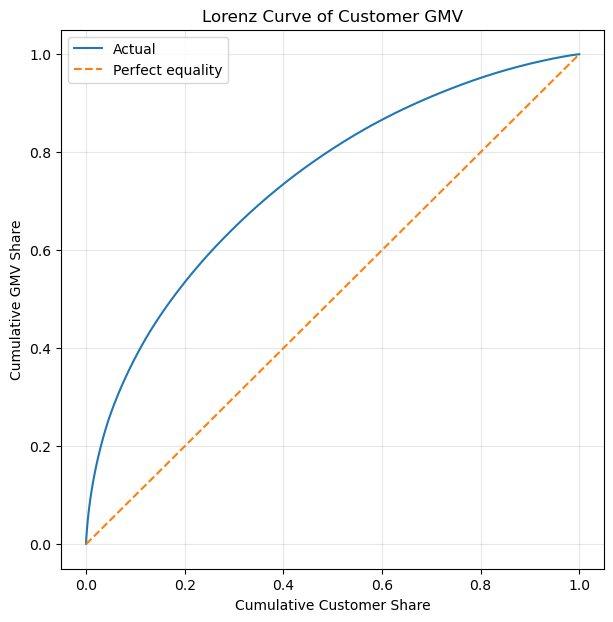

In [18]:

# 累積顧客佔比 vs 累積gmv佔比
plt.figure(figsize=(7, 7))
plt.plot(value_rank["cum_customer_share"], value_rank["cum_gmv_share"], label="Actual")
plt.plot([0, 1], [0, 1], linestyle="--", label="Perfect equality")

plt.xlabel("Cumulative Customer Share")
plt.ylabel("Cumulative GMV Share")
plt.title("Lorenz Curve of Customer GMV")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### RFM分佈分析

In [22]:




# 若需要，可額外限制合理值
rfm = customer_segmentation_v1[
    (customer_segmentation_v1["recency_days"] >= 0) &
    (customer_segmentation_v1["frequency_orders"] >= 1) &
    (customer_segmentation_v1["monetary_total"] >= 0)
].copy()

print("資料筆數：", len(rfm))
display(rfm.head())

資料筆數： 75320


,customer_unique_id,first_purchase_date,last_purchase_date,recency_days,frequency_orders,monetary_total,avg_order_value
0,0000366f3b9a7992bf8c76cfdf3221e2,2018-05-10 10:56:00,2018-05-10 10:56:00,21,1,141.90,141.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,2018-05-07 11:11:00,2018-05-07 11:11:00,24,1,27.19,27.19
2,0000f46a3911fa3c0805444483337064,2017-03-10 21:05:00,2017-03-10 21:05:00,446,1,86.22,86.22
3,0000f6ccb0745a6a4b88665a16c9f078,2017-10-12 20:29:00,2017-10-12 20:29:00,230,1,43.62,43.62
4,0004aac84e0df4da2b147fca70cf8255,2017-11-14 19:45:00,2017-11-14 19:45:00,197,1,196.89,196.89


In [23]:
# RFM描述統計
# =========================
# 1. RFM描述統計
# =========================
rfm_summary = rfm[["recency_days", "frequency_orders", "monetary_total"]].describe(
    percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99]
).T

rfm_summary

,count,mean,std,min,25%,50%,75%,90%,95%,99%,max
recency_days,75320.0,194.324708,131.978216,0.00,85.0,177.0,290.00,392.0,440.0000,489.00,623.00
frequency_orders,75320.0,1.032913,0.205004,1.00,1.0,1.0,1.00,1.0,1.0000,2.00,10.00
monetary_total,75320.0,164.329027,222.754067,10.07,63.0,107.2,181.68,317.8,466.1615,1084.71,13664.08


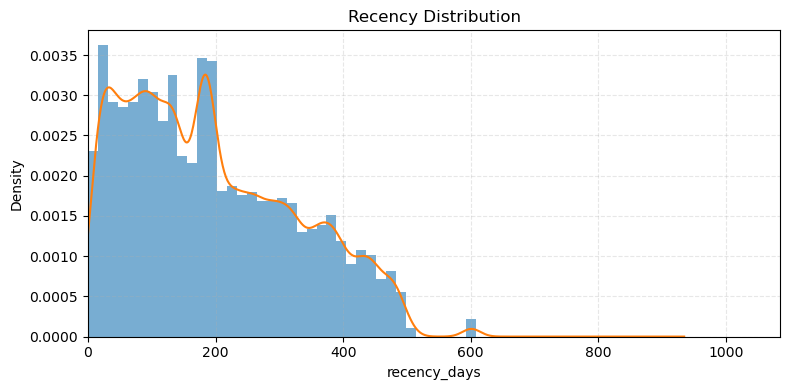

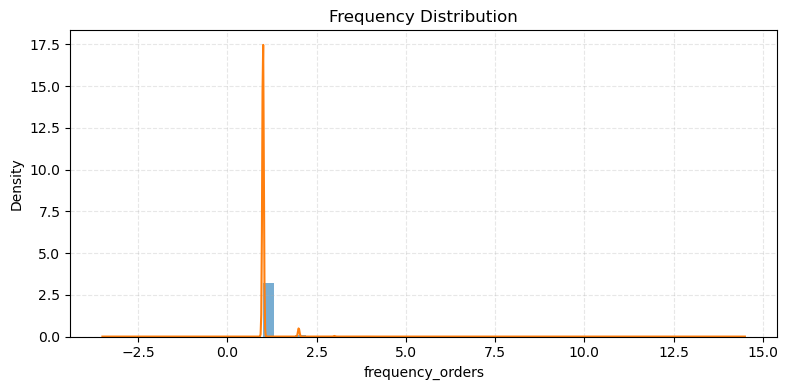

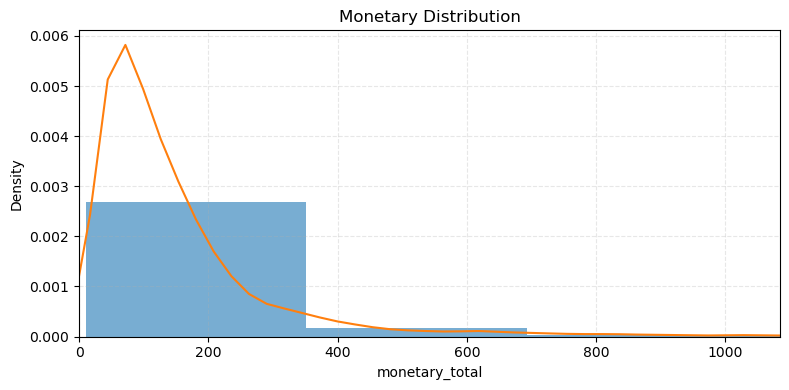

In [36]:
# =========================
# 1. Recency Distribution
# =========================
plt.figure(figsize=(8, 4))
rfm["recency_days"].plot(kind="hist", bins=40, alpha=0.6, density=True)
rfm["recency_days"].plot(kind="kde")

plt.title("Recency Distribution")
plt.xlabel("recency_days")
plt.ylabel("Density")
plt.grid(alpha=0.3, linestyle="--")
plt.xlim(0, rfm["monetary_total"].quantile(0.99))
plt.tight_layout()
plt.show()


# =========================
# 2. Frequency Distribution
# =========================
plt.figure(figsize=(8, 4))
rfm["frequency_orders"].plot(kind="hist", bins=30, alpha=0.6, density=True)
rfm["frequency_orders"].plot(kind="kde")

plt.title("Frequency Distribution")
plt.xlabel("frequency_orders")
plt.ylabel("Density")
plt.grid(alpha=0.3, linestyle="--")
plt.tight_layout()
plt.show()


# =========================
# 3. Monetary Distribution
# =========================
plt.figure(figsize=(8, 4))
rfm["monetary_total"].plot(kind="hist", bins=40, alpha=0.6, density=True)
rfm["monetary_total"].plot(kind="kde")

plt.title("Monetary Distribution")
plt.xlabel("monetary_total")
plt.ylabel("Density")
plt.grid(alpha=0.3, linestyle="--")
plt.xlim(0, rfm["monetary_total"].quantile(0.99))
plt.tight_layout()
plt.show()

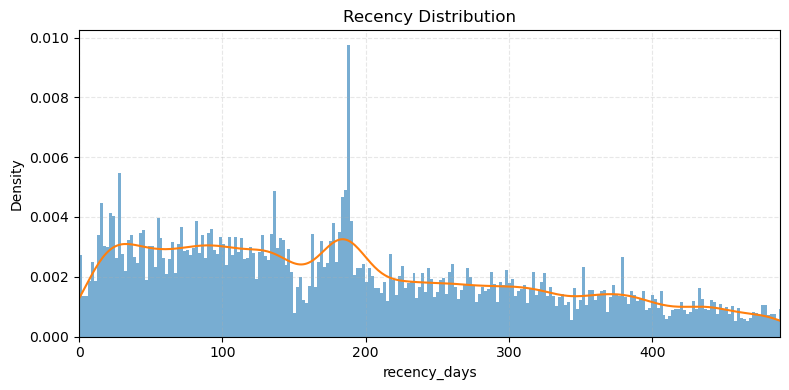

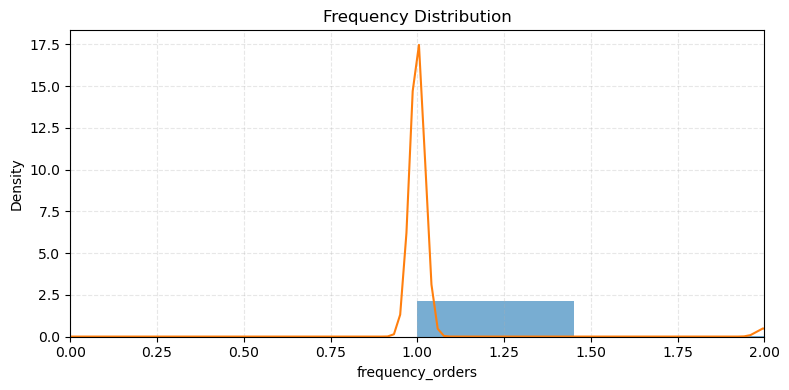

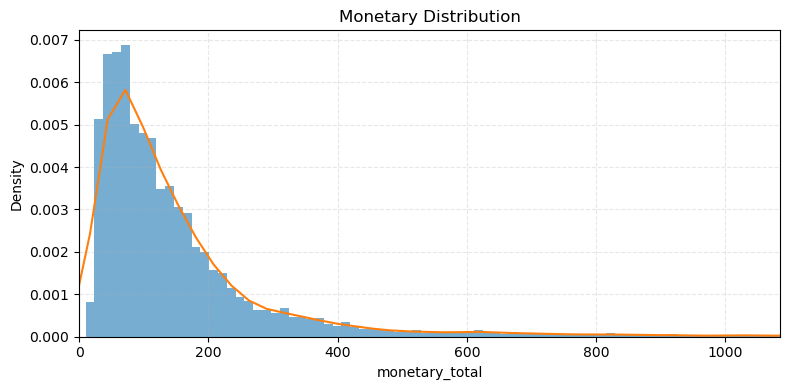

In [32]:

# 設定bin數看分佈
plt.figure(figsize=(8, 4))
rfm["recency_days"].plot(
    kind="hist",
    bins=300,
    alpha=0.6,
    density=True
)
rfm["recency_days"].plot(kind="kde")

plt.title("Recency Distribution")
plt.xlabel("recency_days")
plt.ylabel("Density")
plt.grid(alpha=0.3, linestyle="--")

# 若右尾太長，可限制到 99 分位，讓主體更清楚
plt.xlim(0, rfm["recency_days"].quantile(0.99))

plt.tight_layout()
plt.show()


# ================
# Frequency
# ================
plt.figure(figsize=(8, 4))
rfm["frequency_orders"].plot(
    kind="hist",
    bins=20,
    alpha=0.6,
    density=True
)
rfm["frequency_orders"].plot(kind="kde")

plt.title("Frequency Distribution")
plt.xlabel("frequency_orders")
plt.ylabel("Density")
plt.grid(alpha=0.3, linestyle="--")

# 頻次通常極端右偏，限制到 99 分位比較好看
plt.xlim(0, rfm["frequency_orders"].quantile(0.99))

plt.tight_layout()
plt.show()


# ================
# Monetary
# ================
plt.figure(figsize=(8, 4))
rfm["monetary_total"].plot(
    kind="hist",
    bins=1000,
    alpha=0.6,
    density=True
)
rfm["monetary_total"].plot(kind="kde")

plt.title("Monetary Distribution")
plt.xlabel("monetary_total")
plt.ylabel("Density")
plt.grid(alpha=0.3, linestyle="--")

# 金額通常長尾很重，限制到 99 分位讓圖不要被極端值拉壞
plt.xlim(0, rfm["monetary_total"].quantile(0.99))

plt.tight_layout()
plt.show()

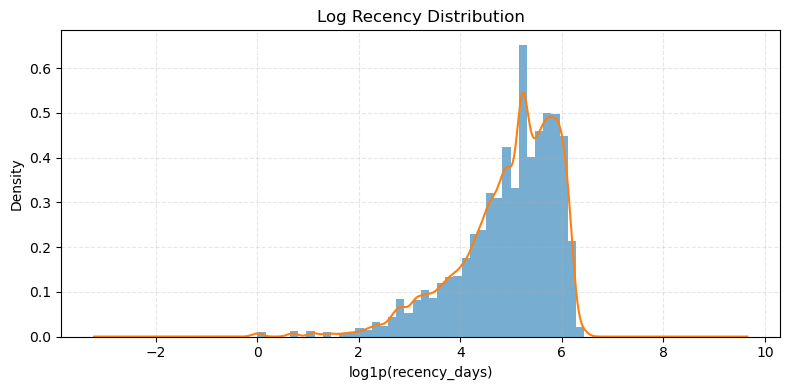

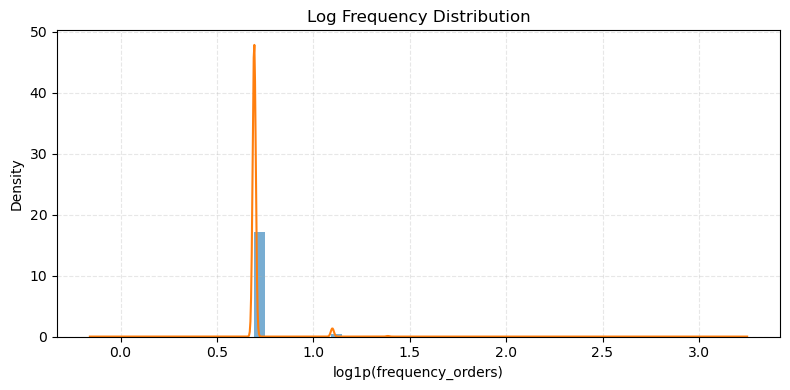

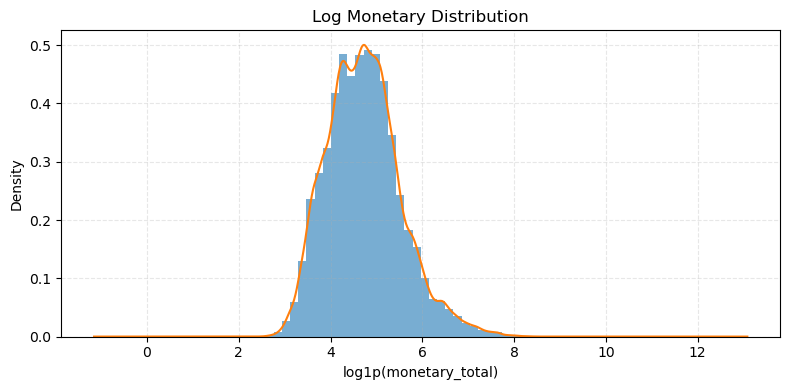

In [33]:
# 取log 看分佈

rfm_plot = rfm.copy()

rfm_plot["log_recency_days"] = np.log1p(rfm_plot["recency_days"])
rfm_plot["log_frequency_orders"] = np.log1p(rfm_plot["frequency_orders"])
rfm_plot["log_monetary_total"] = np.log1p(rfm_plot["monetary_total"])

# =========================
# 1. Log Recency
# =========================
plt.figure(figsize=(8, 4))
rfm_plot["log_recency_days"].plot(kind="hist", bins=40, alpha=0.6, density=True)
rfm_plot["log_recency_days"].plot(kind="kde")

plt.title("Log Recency Distribution")
plt.xlabel("log1p(recency_days)")
plt.ylabel("Density")
plt.grid(alpha=0.3, linestyle="--")

plt.tight_layout()
plt.show()


# =========================
# 2. Log Frequency
# =========================
plt.figure(figsize=(8, 4))
rfm_plot["log_frequency_orders"].plot(kind="hist", bins=30, alpha=0.6, density=True)
rfm_plot["log_frequency_orders"].plot(kind="kde")

plt.title("Log Frequency Distribution")
plt.xlabel("log1p(frequency_orders)")
plt.ylabel("Density")
plt.grid(alpha=0.3, linestyle="--")

plt.tight_layout()
plt.show()


# =========================
# 3. Log Monetary
# =========================
plt.figure(figsize=(8, 4))
rfm_plot["log_monetary_total"].plot(kind="hist", bins=40, alpha=0.6, density=True)
rfm_plot["log_monetary_total"].plot(kind="kde")

plt.title("Log Monetary Distribution")
plt.xlabel("log1p(monetary_total)")
plt.ylabel("Density")
plt.grid(alpha=0.3, linestyle="--")

plt.tight_layout()
plt.show()